In [1]:
# Estas son las dependencias necesarias! descomenta si no las tienes en tu entorno :)

# !pip install numpy pandas matplotlib torch scikit-learn


# Redes neuronales con PyTorch

Esta ayudantía tiene como foco entender rápidamente qué es una red neuronal y luego programar una en PyTorch sobre un problema urbano real.

## Objetivos
- Cargar un dataset desde **Hugging Face**.
- Preparar los datos.
- Definir una red neuronal pequeña en **PyTorch**.
- Entrenarla y evaluarla.
- Jugar con algunos **hiperparámetros** para ver cómo cambia el resultado.

## Caso elegido
Usaremos un problema de **movilidad urbana**:

> **Predecir la demanda de bicicletas compartidas** a partir de variables meteorológicas y temporales.

Esto es útil en ciudades porque permite:
- planificar reposición de bicicletas
- dimensionar operación
- estimar congestión en ciertos horarios
- y apoyar decisiones de movilidad sostenible

---



## 1. Redes neuronales: explicación corta

Una red neuronal es una función parametrizada que aprende a transformar entradas \(x\) en salidas \(y\).

En términos simples:
- recibe variables de entrada
- aplica varias transformaciones lineales y no lineales
- y ajusta sus parámetros para minimizar un error.

### Componentes básicos
- **Capa lineal**: combina variables con pesos y sesgos.
- **Función de activación**: introduce no linealidad (por ejemplo, ReLU).
- **Función de pérdida**: mide qué tan mal está prediciendo.
- **Optimizador**: actualiza los parámetros usando gradiente descendente.

### ¿Dónde se usan?
- **Visión computacional**: clasificación de imágenes, segmentación.
- **Lenguaje natural**: traducción, chatbots, embeddings.
- **Series temporales y tabular**: predicción de demanda, riesgo, precios.
- **Aplicaciones urbanas**:
  - estimación de demanda de transporte
  - predicción de tráfico
  - detección de uso de suelo
  - análisis de imágenes de calles
  - pronóstico de consumo energético o movilidad

En esta ayudantía usaremos una **MLP (Multi-Layer Perceptron)**, es decir, una red neuronal densa sencilla, ideal para comenzar.

In [2]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 3115

# Distintas librerías usan distintas formas de generar números aleatorios
def set_seed(seed: int = 3115) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Si desean correr en CPU simplemente cambien DEVICE a "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("Usando dispositivo:", DEVICE)

Usando dispositivo: mps



## 2. Carga del dataset desde Hugging Face

Usaremos un CSV alojado en Hugging Face con el dataset de **bike sharing demand**.

La idea del problema es predecir `cnt`, es decir, la cantidad total de bicicletas arrendadas en un período, usando variables como:
- temperatura,
- humedad,
- viento,
- día de la semana,
- mes,
- si es feriado,
- condiciones climáticas, etc.


In [3]:
# Si no pueden leer el enlace, descargar desde archivos en canvas
HF_DATA_URL = "https://huggingface.co/spaces/Nagappana/bicycle-rentals/raw/main/bike-sharing-dataset.csv"

df = pd.read_csv(HF_DATA_URL)
print(df.shape)
df.tail(5)

(17379, 14)


,dteday,season,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,2011-05-24,summer,1pm,No,Tue,Yes,NaN,28.66,30.002,46.0,16.9979,38,152,190
17375,2012-04-19,summer,9pm,No,Thu,Yes,NaN,16.44,17.000,55.0,7.0015,27,240,267
17376,2012-01-24,spring,11pm,No,Tue,Yes,Clear,7.04,7.001,76.0,0.0000,19,80,99
17377,2011-01-22,spring,1am,No,Sat,No,Mist,-6.12,-16.000,41.0,26.0027,3,9,12
17378,2012-02-19,spring,1pm,No,Sun,No,Clear,6.10,3.998,49.0,11.0014,64,197,261


- `dteday`: fecha
- `season`: estación del año
- `hr`: hora del día (0–23)
- `holiday`: indica si es feriado
- `weekday`: día de la semana
- `workingday`: indica si es día laboral
- `weathersit`: situación climática
- `temp`: temperatura celsius
- `atemp`: temperatura percibida celsius
- `hum`: humedad relativa normalizada
- `windspeed`: velocidad del viento normalizada
- `casual`: número de usuarios ocasionales
- `registered`: número de usuarios registrados
- `cnt`: número total de bicicletas arrendadas

In [4]:
# Notemos donde tenemos datos nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  str    
 1   season      17379 non-null  str    
 2   hr          17379 non-null  str    
 3   holiday     17379 non-null  str    
 4   weekday     16504 non-null  str    
 5   workingday  17379 non-null  str    
 6   weathersit  16121 non-null  str    
 7   temp        17379 non-null  float64
 8   atemp       17379 non-null  float64
 9   hum         17379 non-null  float64
 10  windspeed   17379 non-null  float64
 11  casual      17379 non-null  int64  
 12  registered  17379 non-null  int64  
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(3), str(7)
memory usage: 1.9 MB


## 3. Filtrado y preparación de datos

* Preparamos los datos de fecha para que sean procesables.
* Para no filtrar información futura, eliminaremos las columnas `casual` y `registered`, porque en conjunto explican directamente `cnt`.
* Debemos tratar con los datos faltantes o NaN. Hay varias alternativas, hoy nos vamos por la fácil.
* ¿Cómo tratamos distintas variables categóricas? ¿Qué opciones hay?
* ¿Y las numéricas? ¿Qué ocurre con la hora y el día?

In [6]:
# Convertimos fecha si existe
df["dteday"] = pd.to_datetime(df["dteday"]) # Convertir a datetime
df["dayofyear"] = df["dteday"].dt.dayofyear # Extraer día del año
df["is_weekend"] = (df["dteday"].dt.dayofweek >= 5).astype(int) # Extraer si es fin de semana

target_col = "cnt"

# Botar columnas que filtran la respuesta o que no aportan información relevante
df_model = df.drop(columns=["casual", "registered", "dteday"])
print("Shape modelado:", df_model.shape)
df_model.head()

# drop nulos
df_model = df_model.dropna()

Shape modelado: (17379, 13)


In [7]:
# 1. variables dummies (útil para variables categóricas)

categorical_cols = [
    'season', 'holiday', 'weekday',
    'workingday', 'weathersit'
]

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
df_model.head()

# 2. Variables cíclicas (útil para variables como hora, día del año, etc)

def parse_hour(x):
    return int(pd.to_datetime(x, format="%I%p").hour)

df_model["hr_num"] = df_model["hr"].apply(parse_hour)
df_model["hr_sin"] = np.sin(2 * np.pi * df_model["hr_num"] / 24)
df_model["hr_cos"] = np.cos(2 * np.pi * df_model["hr_num"] / 24)

df_model["day_sin"] = np.sin(2 * np.pi * df_model["dayofyear"] / 365)
df_model["day_cos"] = np.cos(2 * np.pi * df_model["dayofyear"] / 365)

df_model = df_model.drop(columns=["dayofyear", "hr", "hr_num"])
df_model.head()

,temp,atemp,hum,windspeed,cnt,is_weekend,season_spring,season_summer,season_winter,holiday_Yes,...,weekday_Tue,weekday_Wed,workingday_Yes,weathersit_Heavy Rain,weathersit_Light Rain,weathersit_Mist,hr_sin,hr_cos,day_sin,day_cos
0,6.10,3.0014,49.0,19.0012,139,0,False,False,True,False,...,False,False,True,False,False,True,1.000000e+00,6.123234e-17,-0.811539,0.584298
1,26.78,28.9988,58.0,16.9979,5,0,False,False,False,False,...,False,True,True,False,False,False,8.660254e-01,5.000000e-01,-0.196673,-0.980469
2,3.28,-0.9982,52.0,15.0013,99,0,True,False,False,False,...,False,False,True,False,False,False,2.588190e-01,-9.659258e-01,0.635432,0.772157
3,14.56,15.0002,100.0,6.0032,361,0,False,True,False,False,...,False,False,True,False,False,True,9.659258e-01,-2.588190e-01,0.987349,0.158559
4,16.44,17.0000,52.0,8.9981,203,0,False,False,True,False,...,True,False,True,False,False,False,1.224647e-16,-1.000000e+00,-0.790946,0.611886


In [8]:
# Separación X / y
X = df_model.drop(columns=[target_col]).copy()
y = df_model[target_col].copy()

print("Número de features:", X.shape[1])
print("Target:", target_col)
X.head()

Número de features: 23
Target: cnt


,temp,atemp,hum,windspeed,is_weekend,season_spring,season_summer,season_winter,holiday_Yes,weekday_Mon,...,weekday_Tue,weekday_Wed,workingday_Yes,weathersit_Heavy Rain,weathersit_Light Rain,weathersit_Mist,hr_sin,hr_cos,day_sin,day_cos
0,6.10,3.0014,49.0,19.0012,0,False,False,True,False,True,...,False,False,True,False,False,True,1.000000e+00,6.123234e-17,-0.811539,0.584298
1,26.78,28.9988,58.0,16.9979,0,False,False,False,False,False,...,False,True,True,False,False,False,8.660254e-01,5.000000e-01,-0.196673,-0.980469
2,3.28,-0.9982,52.0,15.0013,0,True,False,False,False,False,...,False,False,True,False,False,False,2.588190e-01,-9.659258e-01,0.635432,0.772157
3,14.56,15.0002,100.0,6.0032,0,False,True,False,False,False,...,False,False,True,False,False,True,9.659258e-01,-2.588190e-01,0.987349,0.158559
4,16.44,17.0000,52.0,8.9981,0,False,False,True,False,False,...,True,False,True,False,False,False,1.224647e-16,-1.000000e+00,-0.790946,0.611886



## 4. Split de entrenamiento, validación y prueba

Haremos una división simple:
- **70% train**
- **15% validation**
- **15% test**

Luego escalaremos las variables numéricas con `StandardScaler`.


In [9]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=SEED
)
# 0.1765 sobre el 85% ≈ 15% del total

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (10720, 23) (10720,)
Val:   (2298, 23) (2298,)
Test:  (2298, 23) (2298,)


In [10]:
# Escalamos los datos para que todas las variables estén en la misma escala,
# lo que permite que el modelo entrene más rápido, de forma más estable y 
# sin que una variable domine a las otras.

numeric_cols = X_train.columns.tolist()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train_np = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
y_val_np = y_val.to_numpy(dtype=np.float32).reshape(-1, 1)
y_test_np = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

print(X_train_scaled[:1])

[[-1.22508922 -1.53208151 -0.97977512  2.10270186 -0.63493414  1.73767015
  -0.58553699 -0.57217986  5.84358973  2.46588346 -0.40849262 -0.41066667
  -0.40864808 -0.40350455 -0.40926963 -1.47204377 -0.01366023 -0.30712247
  -0.62410013 -0.99365186 -0.98723615  0.3758356   1.35417702]]



## 5. Dataset y DataLoader en PyTorch

PyTorch trabaja muy cómodo con objetos `Dataset` y `DataLoader`.


In [11]:
# Convertimos a tensores
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32)

# Creamos datasets simples
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

# Ejemplo de batch
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)
print("Batch y:", yb.shape)

Batch X: torch.Size([64, 23])
Batch y: torch.Size([64, 1])



## 6. Definimos una red neuronal pequeña

Usaremos una MLP con:
- capa de entrada,
- una o dos capas ocultas,
- ReLU,
- salida escalar para regresión.

Como la salida es numérica continua (`cnt`), esto es un problema de **regresión**, no de clasificación.


In [12]:
# MLP más sencillo
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64,32), dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLPRegressor(input_dim=X_train_scaled.shape[1], hidden_dims=(64, 32), dropout=0.1).to(DEVICE)


## 7. Funciones de entrenamiento y evaluación

Vamos a construir funciones reutilizables para:
- entrenar por épocas,
- medir pérdida en validación,
- y luego evaluar en test.

Usaremos:
- **MSELoss** como función de pérdida,
- **Adam** como optimizador.


In [13]:
# Forma más compacta de definir los hiperparámetros de entrenamiento.
@dataclass
class TrainConfig:
    hidden_dims: tuple = (64, 32)
    dropout: float = 0.0
    lr: float = 1e-3
    batch_size: int = 64
    epochs: int = 80

# Calculamos la pérdida en cada batch y luego promediamos para 
# obtener el error del modelo en todo el dataset.
def evaluate_loss(model, loader, criterion):
    model.eval()
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            losses.append(loss.item())

    return float(np.mean(losses))

def predict_model(model, loader):
    model.eval()
    preds_list = []
    targets_list = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            preds = model(X_batch).cpu().numpy()
            preds_list.append(preds)
            targets_list.append(y_batch.numpy())

    y_pred = np.vstack(preds_list).ravel()
    y_true = np.vstack(targets_list).ravel()
    return y_true, y_pred

def train_model(config: TrainConfig):
    model = MLPRegressor(
        input_dim=X_train_scaled.shape[1],
        hidden_dims=config.hidden_dims,
        dropout=config.dropout,
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(1, config.epochs + 1):
        model.train()
        batch_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_loss = evaluate_loss(model, val_loader, criterion)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.3f} | val_loss={val_loss:.3f}")

    y_val_true, y_val_pred = predict_model(model, val_loader)
    y_test_true, y_test_pred = predict_model(model, test_loader)

    metrics = {
        "val_rmse": math.sqrt(mean_squared_error(y_val_true, y_val_pred)),
        "val_mae": mean_absolute_error(y_val_true, y_val_pred),
        "val_r2": r2_score(y_val_true, y_val_pred),
        "test_rmse": math.sqrt(mean_squared_error(y_test_true, y_test_pred)),
        "test_mae": mean_absolute_error(y_test_true, y_test_pred),
        "test_r2": r2_score(y_test_true, y_test_pred),
    }

    return model, pd.DataFrame(history), metrics, (y_test_true, y_test_pred)



## 8. Entrenamos una configuración base


In [14]:

base_config = TrainConfig(
    hidden_dims=(64, 32),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=80,
)

model_base, hist_base, metrics_base, test_preds_base = train_model(base_config)
metrics_base


Epoch 001 | train_loss=58709.489 | val_loss=33355.526
Epoch 010 | train_loss=16451.271 | val_loss=15228.864
Epoch 020 | train_loss=10636.331 | val_loss=9052.363
Epoch 030 | train_loss=9664.162 | val_loss=8034.117
Epoch 040 | train_loss=9276.661 | val_loss=7551.511
Epoch 050 | train_loss=8953.080 | val_loss=7262.264
Epoch 060 | train_loss=8650.503 | val_loss=6943.727
Epoch 070 | train_loss=8368.558 | val_loss=6816.717
Epoch 080 | train_loss=8309.189 | val_loss=6701.065


{'val_rmse': 81.87614204833268,
 'val_mae': 54.838680267333984,
 'val_r2': 0.7981085181236267,
 'test_rmse': 84.03323723942509,
 'test_mae': 55.58509063720703,
 'test_r2': 0.7856581807136536}

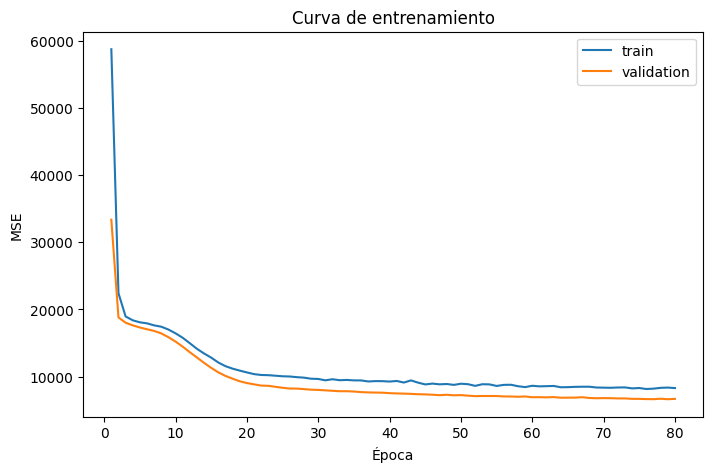

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(hist_base["epoch"], hist_base["train_loss"], label="train")
plt.plot(hist_base["epoch"], hist_base["val_loss"], label="validation")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de entrenamiento")
plt.legend()
plt.show()

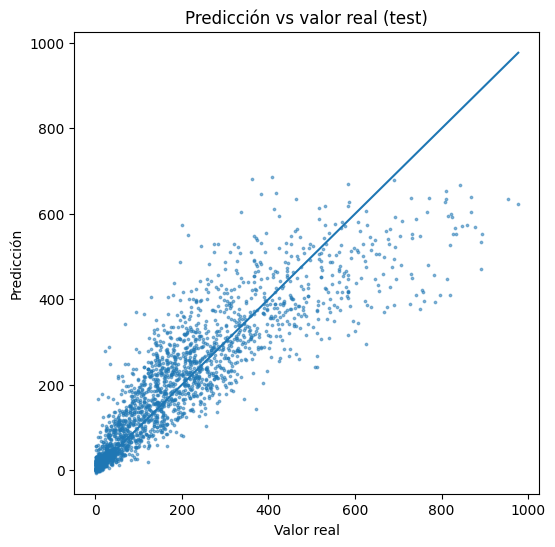

In [16]:
y_test_true, y_test_pred = test_preds_base

plt.figure(figsize=(6, 6))
plt.scatter(y_test_true, y_test_pred, alpha=0.5, s=3)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Predicción vs valor real (test)")
plt.plot([y_test_true.min(), y_test_true.max()],
         [y_test_true.min(), y_test_true.max()])
plt.show()


## 9. Juguemos con hiperparámetros

Ahora veremos algo importante de la práctica real:

> cambiar hiperparámetros cambia el comportamiento del modelo.

Probaremos tres configuraciones:
1. **Red pequeña**
2. **Red base**
3. **Red más grande + learning rate distinto**

No buscamos optimizar al máximo, sino **mostrar el efecto**.


In [17]:
# Esta versión del código permite jugar más con el número de capas ocultas
class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(64, 32), dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLPRegressor(input_dim=X_train_scaled.shape[1], hidden_dims=(64, 32), dropout=0.1).to(DEVICE)
print(model)

MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [18]:

experiments = {
    "small_net": TrainConfig(hidden_dims=(16,), dropout=0.0, lr=1e-3, batch_size=64, epochs=60),
    "base_net": TrainConfig(hidden_dims=(64, 32), dropout=0.1, lr=1e-3, batch_size=64, epochs=80),
    "bigger_net_lower_lr": TrainConfig(hidden_dims=(128, 64, 32), dropout=0.15, lr=5e-4, batch_size=64, epochs=100),
    "bigger_net_lower_lr_high_drop": TrainConfig(hidden_dims=(128, 64, 32), dropout=0.5, lr=5e-4, batch_size=64, epochs=100)
}

results = []
histories = {}

for name, config in experiments.items():
    print("=" * 80)
    print("Experimento:", name)
    model_i, hist_i, metrics_i, _ = train_model(config)
    histories[name] = hist_i

    row = {"experiment": name, **config.__dict__, **metrics_i}
    results.append(row)

results_df = pd.DataFrame(results).sort_values("test_rmse")
results_df


Experimento: small_net
Epoch 001 | train_loss=67991.637 | val_loss=66850.908
Epoch 010 | train_loss=25920.218 | val_loss=23990.158
Epoch 020 | train_loss=18530.836 | val_loss=18236.881
Epoch 030 | train_loss=16416.506 | val_loss=16137.504
Epoch 040 | train_loss=15051.220 | val_loss=14753.151
Epoch 050 | train_loss=13998.065 | val_loss=13701.020
Epoch 060 | train_loss=13192.145 | val_loss=12928.655
Experimento: base_net
Epoch 001 | train_loss=60457.022 | val_loss=37515.174
Epoch 010 | train_loss=16847.457 | val_loss=15658.886
Epoch 020 | train_loss=11233.668 | val_loss=9582.502
Epoch 030 | train_loss=9929.971 | val_loss=8231.612
Epoch 040 | train_loss=9456.559 | val_loss=7683.822
Epoch 050 | train_loss=8958.295 | val_loss=7335.649
Epoch 060 | train_loss=8896.036 | val_loss=7128.390
Epoch 070 | train_loss=8590.739 | val_loss=6871.818
Epoch 080 | train_loss=8394.829 | val_loss=6781.534
Experimento: bigger_net_lower_lr
Epoch 001 | train_loss=56798.924 | val_loss=23372.624
Epoch 010 | train

,experiment,hidden_dims,dropout,lr,batch_size,epochs,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
2,bigger_net_lower_lr,"(128, 64, 32)",0.15,0.0005,64,100,74.483488,49.303547,0.832920,75.895658,50.534027,0.825161
1,base_net,"(64, 32)",0.10,0.0010,64,80,82.362990,55.118954,0.795700,84.310459,55.951622,0.784242
3,bigger_net_lower_lr_high_drop,"(128, 64, 32)",0.50,0.0005,64,100,86.169060,54.554886,0.776382,88.488882,56.809204,0.762326
0,small_net,"(16,)",0.00,0.0010,64,60,113.739332,78.268791,0.610395,115.998169,80.521530,0.591580


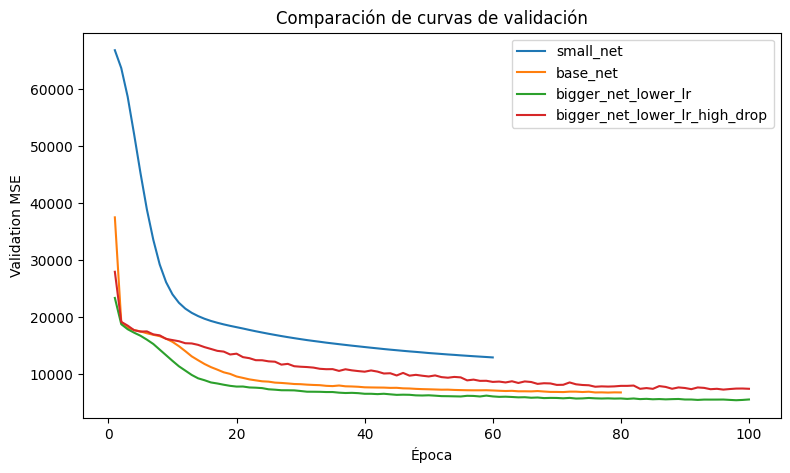

In [19]:

plt.figure(figsize=(9, 5))
for name, hist_i in histories.items():
    plt.plot(hist_i["epoch"], hist_i["val_loss"], label=name)

plt.xlabel("Época")
plt.ylabel("Validation MSE")
plt.title("Comparación de curvas de validación")
plt.legend()
plt.show()



## 10. Interpretación pedagógica

Algunas lecturas típicas:

- Si la red es **demasiado pequeña**, puede tener **underfitting**:
  no logra capturar suficiente estructura de los datos.

- Si la red es **más grande**, puede mejorar, pero también:
  - tardar más,
  - ser más inestable,
  - y sobreajustar si no controlamos bien el entrenamiento.

- El **learning rate** afecta cuánto se mueven los pesos en cada actualización:
  - demasiado alto: entrenamiento inestable,
  - demasiado bajo: entrenamiento muy lento.

- El **dropout** puede ayudar a regularizar.


## 11. Ejercicio sugerido para estudiantes

Jueguen! Cambien los hiperparams. Prueben una o más de estas modificaciones:
1. Cambiar la activación de `ReLU` a `LeakyReLU`.
2. Agregar `BatchNorm1d`.
3. Probar `hidden_dims` en otros valores.
4. Cambiar `batch_size`.
5. Probar una transformación del target, por ejemplo `log1p(cnt)`.
6. Comparar contra una regresión lineal como baseline (Buena práctica).



## 12. Conclusión

En esta ayudantía vimos un pipeline completo y sencillo:

1. cargar datos urbanos reales
2. preparar variables
3. construir una red en PyTorch
4. entrenar
5. evaluar
6. comparar hiperparámetros